## Download onto Google Colab

In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "1TpfM7ohv1uF32a-5m-15-3g5-2fMlE7e"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "pout.tif", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1TpfM7ohv1uF32a-5m-15-3g5-2fMlE7e
To: /content/pout.tif
100%|██████████| 69.0k/69.0k [00:00<00:00, 3.25MB/s]


'pout.tif'

#LAB 2

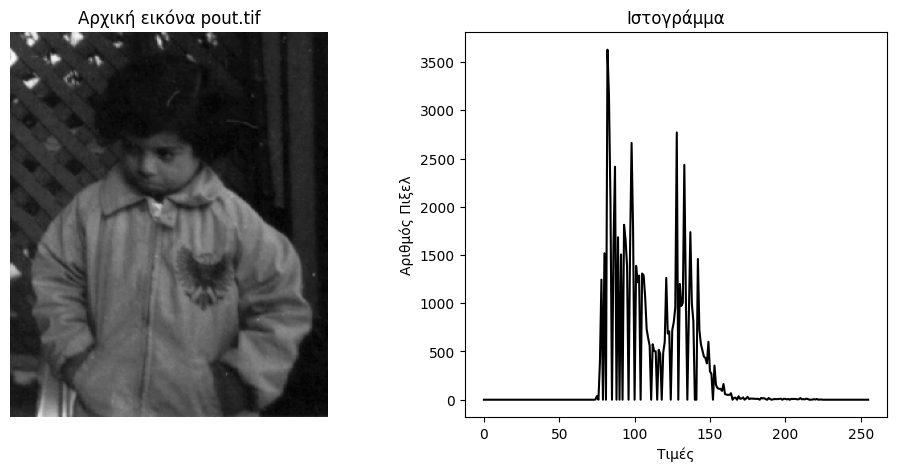

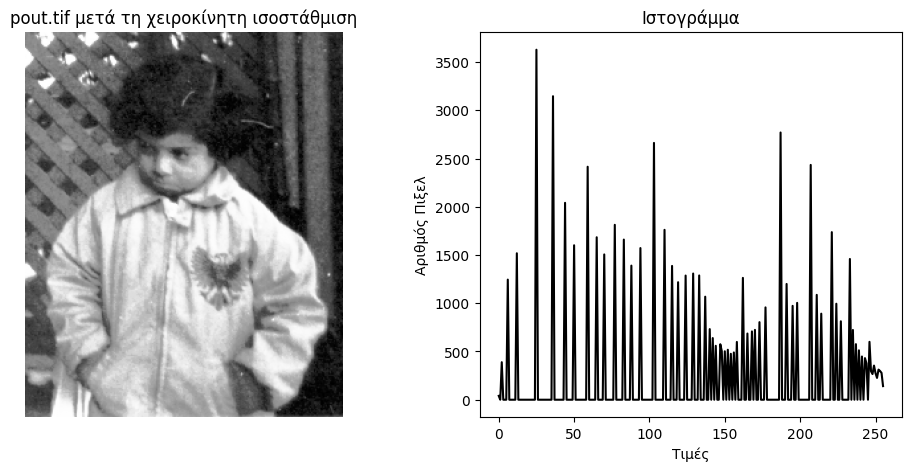

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Βοηθητική συνάρτηση για εμφάνιση εικόνας και ιστογράμματος
def show_image_and_hist(image, title="Image", is_gray=True):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    if is_gray:
        plt.imshow(image, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if is_gray:
        hist = cv2.calcHist([image], [0], None, [256], [0,256])
        plt.plot(hist, color='black')
    else:
        colors = ('b','g','r')
        for i, col in enumerate(colors):
            hist = cv2.calcHist([image], [i], None, [256], [0,256])
            plt.plot(hist, color=col)
    plt.title("Ιστογράμμα")
    plt.xlabel("Τιμές")
    plt.ylabel("Αριθμός Πιξελ")
    plt.show()

# Λειτουργία για χειροκίνητη ισοστάθμιση ιστογράμματος χωρίς χρήση της cdf
def my_equalize_hist(img):
    # Δημιουργούμε ένα κενό image ίδιων διαστάσεων
    equalized = np.zeros_like(img)
    total_pixels = img.size  # συνολικός αριθμός pixel

    # Για κάθε δυνατή τιμή 0-255, υπολογίζουμε πόσα pixels έχουν τιμή <= i
    # και καθορίζουμε την νέα τιμή βάσει του πλήθους αυτών των pixels.
    for i in range(256):
        count = np.sum(img <= i)
        new_val = int(round(count / total_pixels * 255))
        # Αναθέτουμε την νέα τιμή σε όλα τα pixels που είχαν τιμή i
        equalized[img == i] = new_val

    return equalized

# ---------------------------
# Άσκηση 1: Ισοστάθμιση Ιστογράμματος για την εικόνα pout.tif
# ---------------------------
# Ανάγνωση εικόνας σε grayscale
img_pout = cv2.imread("pout.tif", cv2.IMREAD_GRAYSCALE)
if img_pout is None:
    raise FileNotFoundError("Δεν βρέθηκε το αρχείο pout.tif.")

# Εμφάνιση αρχικής εικόνας και ιστογράμματος
show_image_and_hist(img_pout, title="Αρχική εικόνα pout.tif")

# Εφαρμογή της χειροκίνητης ισοστάθμισης
img_pout_eq_manual = my_equalize_hist(img_pout)

# Εμφάνιση εικόνας μετά την ισοστάθμιση και του αντίστοιχου ιστογράμματος
show_image_and_hist(img_pout_eq_manual, title="pout.tif μετά τη χειροκίνητη ισοστάθμιση")


In [ ]:
import gdown

# Replace the ID with the actual file ID from Google Drive link
#file_id = "1cd2g_6jt7Ccnv8IVNQdFL_jmVn4lep-n"
file_id_grey = "10UXyMFm0X4KQxjM83x_Pc58rWfY2HAJV"
gdown.download(f"https://drive.google.com/uc?id={file_id_grey}", "circuit.tif", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=10UXyMFm0X4KQxjM83x_Pc58rWfY2HAJV
To: /content/circuit.tif
100%|██████████| 76.8k/76.8k [00:00<00:00, 2.98MB/s]


'circuit.tif'

Εξομάλυνση με Salt & Pepper Θόρυβο (circuit.tif)


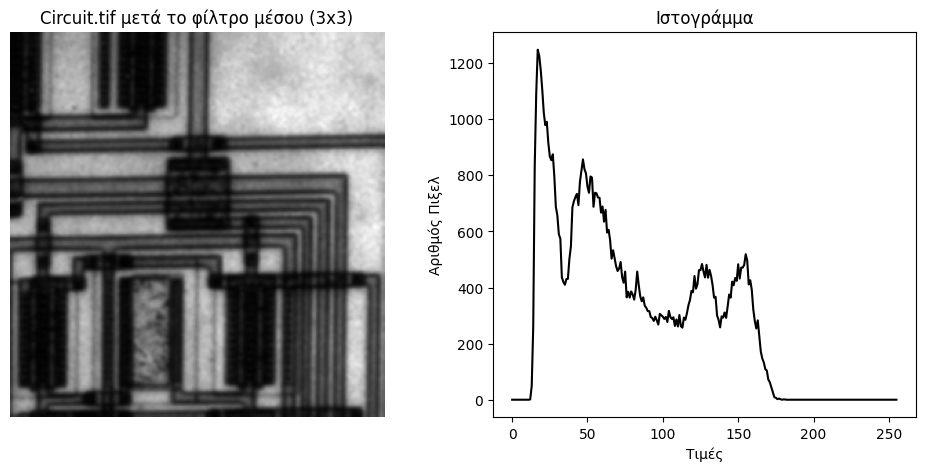

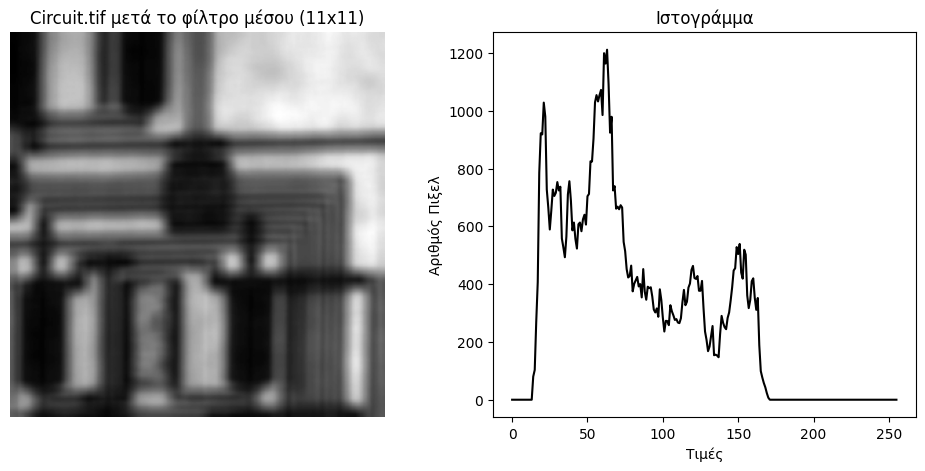

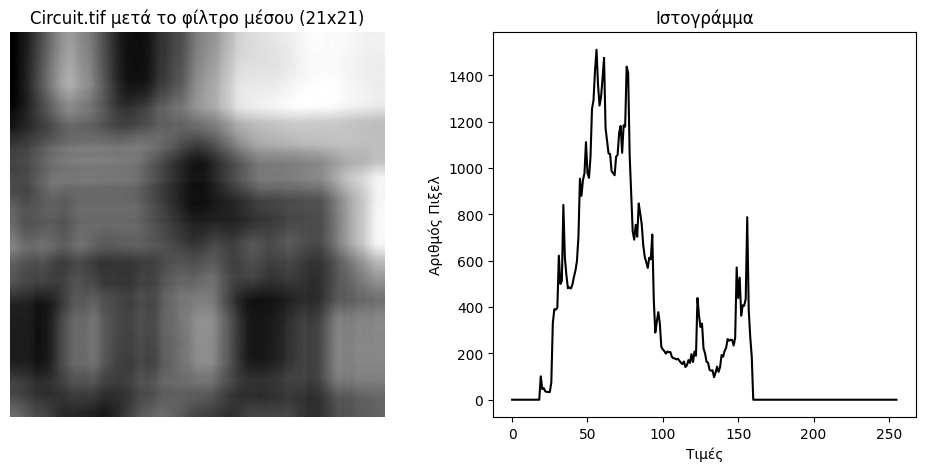

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Άσκηση 2: Εξομάλυνση με Salt & Pepper Θόρυβο (circuit.tif)
# ---------------------------
# Συνάρτηση για προσθήκη salt & pepper θορύβου
def add_salt_pepper_noise(image, prob):
    noisy = image.copy()
    # Υπολογισμός του αριθμού των pixel για θόρυβο
    num_salt = np.ceil(prob * image.size * 0.5).astype(int)
    num_pepper = np.ceil(prob * image.size * 0.5).astype(int)

    # Salt (λευκά pixels)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper (μαύρα pixels)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

# Διαβάζουμε την εικόνα circuit.tif (σε grayscale)
img_circuit = cv2.imread("circuit.tif", cv2.IMREAD_GRAYSCALE)
if img_circuit is None:
    raise FileNotFoundError("Δεν βρέθηκε το αρχείο circuit.tif.")

# Προσθήκη θορύβου salt & pepper με πιθανότητα 0.1
img_circuit_noisy = add_salt_pepper_noise(img_circuit, 0.4)
#show_image_and_hist(img_circuit_noisy, title="Circuit.tif με Salt & Pepper θόρυβο")

# Εφαρμογή φίλτρου μέσου 3x3
img_circuit_mean3 = cv2.blur(img_circuit, (3,3))
img_circuit_mean11 = cv2.blur(img_circuit, (11,11))
img_circuit_mean21 = cv2.blur(img_circuit, (41,41))
show_image_and_hist(img_circuit_mean3, title="Circuit.tif μετά το φίλτρο μέσου (3x3)")
show_image_and_hist(img_circuit_mean11, title="Circuit.tif μετά το φίλτρο μέσου (11x11)")
show_image_and_hist(img_circuit_mean21, title="Circuit.tif μετά το φίλτρο μέσου (21x21)")

# Εφαρμογή φίλτρου μεσαίου 3x3
#img_circuit_median1 = cv2.medianBlur(img_circuit_noisy, 3)
#img_circuit_median2 = cv2.medianBlur(img_circuit_noisy, 5)
#img_circuit_median3 = cv2.medianBlur(img_circuit_noisy, 11)
#img_circuit_median4 = cv2.medianBlur(img_circuit_noisy, 21)
#show_image_and_hist(img_circuit_median1, title="Circuit.tif μετά το φίλτρο μεσαίου 1 x (3x3)")
#show_image_and_hist(img_circuit_median2, title="Circuit.tif μετά το φίλτρο μεσαίου 1 x (5x5)")
#show_image_and_hist(img_circuit_median3, title="Circuit.tif μετά το φίλτρο μεσαίου 1 x (11x11)")
#show_image_and_hist(img_circuit_median4, title="Circuit.tif μετά το φίλτρο μεσαίου 1 x (21x21)")